# Imports and functions

In [2]:
import cooler

# Change this path according to your installation
genome_id = "Vul.DToL"
cool_path = f"/home/amergez/SPA-C/datasets_v2/{genome_id}/aligned/{genome_id}.JHE.mcool::/resolutions/5000"

cool = cooler.Cooler(cool_path)
mat = cool.matrix(balance=False)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

def parse_matrices(ctg1, ctg2, o1, o2, cool):
    mat = cool.matrix(balance=False)
    chromsizes = cool.chromsizes.to_dict()

    if chromsizes[ctg1] >= 50000:
        if o1 == "F":
            T1 = (ctg1, int((chromsizes[ctg1]-50000)//5000*5000), int(chromsizes[ctg1]//5000*5000))
        else:
            T1 = (ctg1, 0, 50000)
    else:
        T1 = (ctg1, 0, int(chromsizes[ctg1]//5000*5000))

    if o1 == "F":
        c1 = np.array(mat.fetch(T1, T1))
    else:
        c1 = np.rot90(np.array(mat.fetch(T1, T1)), k=2)

    if chromsizes[ctg2] >= 50000:
        if o2 == "R":
            T2 = (ctg2, int((chromsizes[ctg2]-50000)//5000*5000), int(chromsizes[ctg2]//5000*5000))
        else:
            T2 = (ctg2, 0, 50000)
    else:
        T2 = (ctg2, 0, int(chromsizes[ctg2]//5000*5000))

    if o2 == "F":
        c2 = np.array(mat.fetch(T2, T2))
    else:
        c2 = np.rot90(np.array(mat.fetch(T2, T2)), k=2)

    if o1 == "F" and o2 == "F":
        c1x2 = np.array(mat.fetch(T1, T2))
        c2x1 = np.array(mat.fetch(T2, T1))
    elif o1 == "R" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0,1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0,1))
    elif o1 == "F" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0))
    elif o1 == "R" and o2 == "F":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (1))

    return c1, c2, c1x2, c2x1

# Stats

In [4]:
from scipy.stats import mannwhitneyu

def get_values_inter(ctg1, ctg2, ctg3, o1, o2, o3, cool):
    n_OC = parse_matrices(ctg1, ctg3, o1, o3, cool)[3].reshape(-1) # Original inter counts

    n_N1 = parse_matrices(ctg1, ctg2, o1, o2, cool)[3].reshape(-1)
    n_N2 = parse_matrices(ctg2, ctg3, o2, o3, cool)[3].reshape(-1)
    n_New = np.concatenate([n_N1, n_N2])
    
    #print(n_OC, n_OC.shape)
    #print(n_N1, n_N1.shape)
    #print(n_N2, n_N2.shape)
    #print(n_New, n_New.shape)
    print(n_OC.shape, n_New.shape)

    #fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
    #sns.histplot(n_OC, ax=axs[0])
    #sns.histplot(n_New, ax=axs[1])

    #plt.show()

    test = mannwhitneyu(n_New, n_OC, alternative="greater")
    print(test)
    return test[1]

In [5]:
list_of_inserts = [
    ("contig_6", "contig_2176", "contig_7", "F", "F", "F"),
    ("contig_192", "contig_2182", "contig_193", "F", "F", "F"),
    ("contig_1066", "contig_2257", "contig_1067", "F", "F", "F"),
    ("contig_1039", "contig_2208", "contig_1040", "F", "R", "F"),
    ("contig_998", "contig_2262", "contig_999", "F", "R", "F"),
    ("contig_114", "contig_2147", "contig_115", "F", "R", "F"),
    ("contig_83", "contig_1919", "contig_84", "F", "R", "F"),
    ("contig_1117", "contig_2213", "contig_1118", "F", "R", "F"),
    ("contig_1200", "contig_2171", "contig_1201", "F", "R", "F"),
]
out = "PAPER_ASM_IMPRV.csv" # The result is available in Results/PAPER_ASM_IMPRV.csv also
with open(out, "w") as handle:
    handle.write(f"CTG_1,CTG_2,CTG_3,p-value\n")
    for info in list_of_inserts:
        res = get_values_inter(info[0], info[1], info[2], info[3], info[4], info[5], cool)
        handle.write(f"{info[0]}:{info[3]},{info[1]}:{info[4]},{info[2]}:{info[5]},{res}\n")

import pandas as pd
df = pd.read_csv(out, header=0)
df[["ID", "_"]] = df["CTG_1"].str.split(":", n=1,expand=True)
df.drop(columns="_", inplace=True)
df.set_index("ID", inplace=True)
df

(100,) (120,)
MannwhitneyuResult(statistic=np.float64(8942.0), pvalue=np.float64(1.687474769822412e-10))
(100,) (120,)
MannwhitneyuResult(statistic=np.float64(9255.0), pvalue=np.float64(1.9075791479854486e-12))
(100,) (80,)
MannwhitneyuResult(statistic=np.float64(5999.5), pvalue=np.float64(3.9210099942959295e-09))
(100,) (120,)
MannwhitneyuResult(statistic=np.float64(9348.5), pvalue=np.float64(4.75632178905865e-13))
(100,) (80,)
MannwhitneyuResult(statistic=np.float64(6640.5), pvalue=np.float64(1.2740166541593472e-14))
(100,) (160,)
MannwhitneyuResult(statistic=np.float64(12760.5), pvalue=np.float64(3.202552156881787e-16))
(100,) (200,)
MannwhitneyuResult(statistic=np.float64(13128.0), pvalue=np.float64(4.8450522455544295e-06))
(100,) (100,)
MannwhitneyuResult(statistic=np.float64(6680.5), pvalue=np.float64(1.951646931531379e-05))
(100,) (140,)
MannwhitneyuResult(statistic=np.float64(10587.5), pvalue=np.float64(6.057597395218522e-12))


,CTG_1,CTG_2,CTG_3,p-value
ID,,,,
contig_6,contig_6:F,contig_2176:F,contig_7:F,1.687475e-10
contig_192,contig_192:F,contig_2182:F,contig_193:F,1.907579e-12
contig_1066,contig_1066:F,contig_2257:F,contig_1067:F,3.921010e-09
contig_1039,contig_1039:F,contig_2208:R,contig_1040:F,4.756322e-13
contig_998,contig_998:F,contig_2262:R,contig_999:F,1.274017e-14
contig_114,contig_114:F,contig_2147:R,contig_115:F,3.202552e-16
contig_83,contig_83:F,contig_1919:R,contig_84:F,4.845052e-06
contig_1117,contig_1117:F,contig_2213:R,contig_1118:F,1.951647e-05
contig_1200,contig_1200:F,contig_2171:R,contig_1201:F,6.057597e-12


# Viz

## Viz exemple

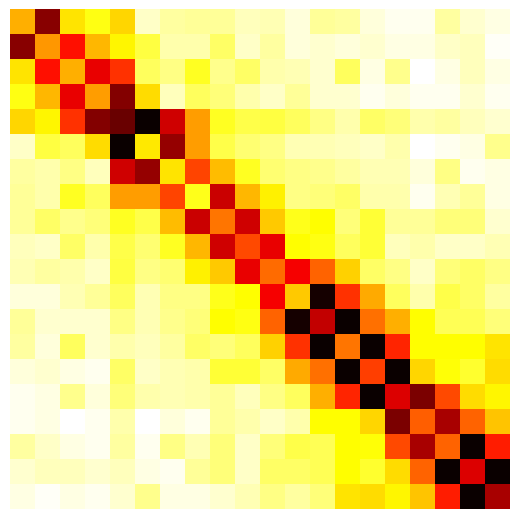

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

arr = np.array(mat.fetch(("contig_1", 1000000, 1100000), ("contig_1", 1000000, 1100000)))
arr = arr.astype(np.float32)
np.divide(arr, 105.0, out=arr)
np.clip(arr, 0, 1, out=arr)

fig, ax = plt.subplots(1,1, figsize=(5,5), dpi=100)
ax.matshow(arr, cmap="hot_r")
plt.axis('off')

plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1,
        wspace=0
    )
plt.savefig(f"/home/amergez/DLScaff/datasets_v2/{genome_id}/aligned/CTG_1_example.png")
plt.show()

In [3]:
cool.chromsizes.to_dict()

{'contig_1': 3304418,
 'contig_2': 1064225,
 'contig_3': 368148,
 'contig_4': 465000,
 'contig_5': 75000,
 'contig_6': 2189711,
 'contig_7': 654794,
 'contig_8': 530000,
 'contig_9': 2415000,
 'contig_10': 444198,
 'contig_11': 2754744,
 'contig_12': 2594077,
 'contig_13': 205000,
 'contig_14': 132690,
 'contig_15': 532217,
 'contig_16': 1384518,
 'contig_17': 520000,
 'contig_18': 517608,
 'contig_19': 40000,
 'contig_20': 789070,
 'contig_21': 790000,
 'contig_22': 2209244,
 'contig_23': 1090000,
 'contig_24': 433433,
 'contig_25': 4292509,
 'contig_26': 1618694,
 'contig_27': 155000,
 'contig_28': 832450,
 'contig_29': 2243730,
 'contig_30': 583611,
 'contig_31': 1855000,
 'contig_32': 8520000,
 'contig_33': 860000,
 'contig_34': 2190000,
 'contig_35': 1050000,
 'contig_36': 1610000,
 'contig_37': 1480000,
 'contig_38': 228647,
 'contig_39': 50000,
 'contig_40': 382120,
 'contig_41': 2777683,
 'contig_42': 2442287,
 'contig_43': 234860,
 'contig_44': 117591,
 'contig_45': 198712,
 '

In [4]:
def gen_hic_mat(contigs, cool, savefig=None, return_fig=False):
    ALL_MAT = []
    chromsizes = cool.chromsizes.to_dict()

    CUM_SIZES = [0]
    cum_size = 0
    for i in range(len(contigs)-1):
        print("CUM_SIZES :", contigs[i])

        if chromsizes[contigs[i]] < 50000:
            _size = len(cool.bins().fetch((contigs[i])))
        else:
            _size = len(cool.bins().fetch((contigs[i], chromsizes[contigs[i]] - 50000, chromsizes[contigs[i]])))
        
        cum_size += _size
        CUM_SIZES.append(cum_size)

    for i in range(1):
        if chromsizes[contigs[i]] < 50000:
            _size = len(cool.bins().fetch((contigs[-1])))
        else:
            _size = len(cool.bins().fetch((contigs[-1], 0, 50000)))
        cum_size += _size
        CUM_SIZES.append(cum_size)

    print("CUM_SIZES :",CUM_SIZES)
    ADDED = [False for k in range(len(contigs))]
    FMAT = np.zeros((CUM_SIZES[-1], CUM_SIZES[-1]))
    FBIS = np.zeros((CUM_SIZES[-1], CUM_SIZES[-1]))
    legend_elements = []
    avail_val = 0
    
    for i in range(len(contigs)-1):
        for j in range(i+1, len(contigs)):
            print(f"{contigs[i]}:{i}, {contigs[j]}:{j}")
            # Add adjacent mat    
            c1, c2, c1x2, c2x1 = parse_matrices(contigs[i], contigs[j], cool)
            

            if not ADDED[i]: # Adding the diagonal if not already
                FMAT[CUM_SIZES[i]:CUM_SIZES[i+1],CUM_SIZES[i]:CUM_SIZES[i+1]] = c1
                FBIS[CUM_SIZES[i]:CUM_SIZES[i+1],CUM_SIZES[i]:CUM_SIZES[i+1]] = np.ones(c1.shape)*avail_val
                legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=contigs[i]))
                avail_val += 1
                ADDED[i] = True
            if not ADDED[j]: # Adding the diagonal if not already
                FMAT[CUM_SIZES[j]:CUM_SIZES[j+1],CUM_SIZES[j]:CUM_SIZES[j+1]] = c2 
                FBIS[CUM_SIZES[j]:CUM_SIZES[j+1],CUM_SIZES[j]:CUM_SIZES[j+1]] = np.ones(c2.shape)*avail_val
                legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=contigs[j]))
                avail_val += 1
                ADDED[j] = True

            try:
                FMAT[CUM_SIZES[i]:CUM_SIZES[i+1], CUM_SIZES[j]:CUM_SIZES[j+1]] = c1x2
                FMAT[CUM_SIZES[j]:CUM_SIZES[j+1], CUM_SIZES[i]:CUM_SIZES[i+1]] = c2x1
    
                FBIS[CUM_SIZES[i]:CUM_SIZES[i+1], CUM_SIZES[j]:CUM_SIZES[j+1]] = np.ones(c1x2.shape)*avail_val
                FBIS[CUM_SIZES[j]:CUM_SIZES[j+1], CUM_SIZES[i]:CUM_SIZES[i+1]] = np.ones(c2x1.shape)*avail_val
                legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=f"{contigs[i]}|{contigs[j]}"))
                avail_val += 1
            except:
                raise ValueError(f"{contigs[i]}, {contigs[j]}")

    fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi=300)
    
    
    ax[0].matshow(FMAT, cmap="hot_r")
    #ax[0].axis('off')
    ticks_positions = [k-.5 for k in CUM_SIZES]
    ticks_labels = ["" for k in CUM_SIZES]
    
    ax[0].set_xticks(ticks_positions)
    ax[0].set_xticklabels(ticks_labels)
    ax[0].set_yticks(ticks_positions)
    ax[0].set_yticklabels(ticks_labels)

    # Adding chrom_ranges
    for pos in range(len(CUM_SIZES)-1):
        mid_pos = (CUM_SIZES[pos]+CUM_SIZES[pos+1])/2-.5
        label = contigs[pos]
        
        ax[0].text(mid_pos, -1, label, ha="center", va="center", fontsize=5, fontweight="bold")
        ax[0].text(-1, mid_pos, label, ha="center", va="center", fontsize=5, fontweight="bold", rotation="vertical")
    

    tab10_colors = plt.cm.tab10(range(avail_val))
    custom_cmap = ListedColormap(tab10_colors)
    ax[1].matshow(FBIS, cmap=custom_cmap)
    ax[1].legend(handles=legend_elements, loc='upper right', fontsize=5)
    ax[1].axis('off')

    plt.tight_layout()

    plt.savefig(savefig)
    plt.show()

In [5]:
contigs = ["contig_6", "contig_7"]
gen_hic_mat(contigs, cool, savefig=f"/home/amergez/DLScaff/datasets_v2/{genome_id}/aligned/CTG_6-7.png")

CUM_SIZES : contig_6
CUM_SIZES : [0, 11, 21]
contig_6:0, contig_7:1


TypeError: parse_matrices() missing 2 required positional arguments: 'o2' and 'cool'

In [6]:
contigs = ["contig_6", "contig_2176", "contig_7"]
gen_hic_mat(contigs, cool, savefig=f"/home/amergez/DLScaff/datasets_v2/{genome_id}/aligned/CTG_6-2176-7.png")

CUM_SIZES : contig_6
CUM_SIZES : contig_2176
CUM_SIZES : [0, 11, 18, 28]
contig_6:0, contig_2176:1


TypeError: parse_matrices() missing 2 required positional arguments: 'o2' and 'cool'

## Figure

In [8]:
from matplotlib.patches import ConnectionPatch
import string

def gen_improvfig(contigs_list, cool, savefig, figsize=(10, 10), fs=14):
    plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})
    
    fig, axs = plt.subplots(len(contigs_list),2, figsize=figsize, dpi=600)
    chromsizes = cool.chromsizes.to_dict()
    CUM_SIZES = {}
    for K in range(len(contigs_list)):
        CUM_SIZES[K] = {}
        for L in range(len(contigs_list[K])):
            contigs = [k.split(":")[0] for k in contigs_list[K][L]]
            order = [k.split(":")[1] for k in contigs_list[K][L]]
            
            ALL_MAT = []
            CUM_SIZES[K][L] = [0]
            cum_size = 0
            for i in range(len(contigs)-1):
                print("Contigs :", contigs[i])
        
                if chromsizes[contigs[i]] < 50000:
                    _size = len(cool.bins().fetch((contigs[i], 0, int(chromsizes[contigs[i]]//5000*5000))))
                else:
                    if order[i] == "F":
                        _size = len(cool.bins().fetch((contigs[i], int((chromsizes[contigs[i]] - 50000)//5000*5000), int(chromsizes[contigs[i]]//5000*5000))))
                    else:
                        _size = len(cool.bins().fetch((contigs[i], 0, 50000)))
                cum_size += _size
                CUM_SIZES[K][L].append(cum_size)
        
            for i in range(1):
                if chromsizes[contigs[i]] < 50000:
                    _size = len(cool.bins().fetch((contigs[-1], 0, int(chromsizes[contigs[-1]]//5000*5000))))
                else:
                    if order[i] == "F":
                        _size = len(cool.bins().fetch((contigs[-1], 0, 50000)))
                    else:
                        _size = len(cool.bins().fetch((contigs[-1], int((chromsizes[contigs[i]] - 50000)//5000*5000), int(chromsizes[contigs[i]]//5000*5000))))
                cum_size += _size
                CUM_SIZES[K][L].append(cum_size)
        
            print("CUM_SIZES :",CUM_SIZES[K][L])
            ADDED = [False for k in range(len(contigs))]
            FMAT = np.zeros((CUM_SIZES[K][L][-1], CUM_SIZES[K][L][-1]))
            FBIS = np.zeros((CUM_SIZES[K][L][-1], CUM_SIZES[K][L][-1]))
            legend_elements = []
            avail_val = 0
            
            for i in range(len(contigs)-1):
                for j in range(i+1, len(contigs)):
                    print(f"{contigs[i]}:{i}, {contigs[j]}:{j}")
                    # Add adjacent mat    
                    c1, c2, c1x2, c2x1 = parse_matrices(contigs[i], contigs[j], order[i], order[j], cool)
                    
        
                    if not ADDED[i]: # Adding the diagonal if not already
                        FMAT[CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1],CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1]] = c1 
                        FBIS[CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1],CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1]] = np.ones(c1.shape)*avail_val
                        legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=contigs[i]))
                        avail_val += 1
                        ADDED[i] = True
                        
                    if not ADDED[j]: # Adding the diagonal if not already
                        FMAT[CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1],CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1]] = c2 
                        FBIS[CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1],CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1]] = np.ones(c2.shape)*avail_val
                        legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=contigs[j]))
                        avail_val += 1
                        ADDED[j] = True
        
                    try:
                        FMAT[CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1], CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1]] = c1x2
                        FMAT[CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1], CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1]] = c2x1
            
                        FBIS[CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1], CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1]] = np.ones(c1x2.shape)*avail_val
                        FBIS[CUM_SIZES[K][L][j]:CUM_SIZES[K][L][j+1], CUM_SIZES[K][L][i]:CUM_SIZES[K][L][i+1]] = np.ones(c2x1.shape)*avail_val
                        legend_elements.append(Patch(facecolor=plt.cm.tab10(avail_val), label=f"{contigs[i]}|{contigs[j]}"))
                        avail_val += 1
                    except:
                        raise ValueError(f"{contigs[i]}, {contigs[j]}")
    
            # Normalisation
            FMAT = FMAT.astype(np.float32)
            np.divide(FMAT, 105.0, out=FMAT)
            np.clip(FMAT, 0, 1, out=FMAT)
            
            axs[K, L].matshow(FMAT, cmap="hot_r")
            #ax[0].axis('off')
            ticks_positions = [k-.5 for k in CUM_SIZES[K][L]]
            ticks_labels = ["" for k in CUM_SIZES[K][L]]
            
            axs[K, L].set_xticks(ticks_positions)
            axs[K, L].set_xticklabels(ticks_labels)
            axs[K, L].set_yticks(ticks_positions)
            axs[K, L].set_yticklabels(ticks_labels)
            if L > 0:
                axs[K, L].yaxis.set_ticks_position('right')
        
            # Adding chrom_ranges
            for pos in range(len(CUM_SIZES[K][L])-1):
                mid_pos = (CUM_SIZES[K][L][pos]+CUM_SIZES[K][L][pos+1])/2-.5
                label = contigs[pos].replace("contig", "ctg")
                
                if L == 0:
                    axs[K, L].text(-1.5, mid_pos, label, ha="center", va="center", fontsize=fs, rotation="vertical")
                    axs[K, L].text(mid_pos, CUM_SIZES[K][L][-1]+0.5, label, ha="center", va="center", fontsize=fs)
                else:
                    axs[K, L].text(CUM_SIZES[K][L][-1]+1, mid_pos, label, ha="center", va="center", fontsize=fs, rotation=-90)
                    axs[K, L].text(mid_pos, CUM_SIZES[K][L][-1]+(CUM_SIZES[K][L][-1]*0.5/CUM_SIZES[K][L-1][-1])+.2, label, ha="center", va="center", fontsize=fs)
                    print(CUM_SIZES[K][L][-1]*0.5/CUM_SIZES[K][L-1][-1])

        # Adding LETTER
        axs[K, 0].annotate(
            list(string.ascii_uppercase)[K],
            xy=(-0.1, 1.1),
            xycoords="axes fraction",
            fontsize=fs+3,
            fontweight="bold",
            color="black",
            va="top",
            ha="left",
        )

        # Adding P-VALUE
        axs[K, 1].annotate(
            f"p-value: {df.loc[contigs[0].split(':')[0], 'p-value']:.2e}",
            xy=(0.05, 0.1),
            xycoords="axes fraction",
            fontsize=fs,
            color="black",
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.3", edgecolor="white", facecolor="white", linewidth=1)
        )
    
        if K == 0:
            axs[K, 0].set_title("Before correction", fontsize=fs, pad=10)#, fontweight="bold")
            axs[K, 1].set_title("After correction", fontsize=fs, pad=10)#, fontweight="bold")
    
        ## Adding visual guidelines
        # Line on the left panel
        axs[K, 0].plot([CUM_SIZES[K][0][1]-.5, CUM_SIZES[K][0][2]-.5], [CUM_SIZES[K][0][1]-.5, CUM_SIZES[K][0][1]-.5],
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )

        # Lines on the right panel
        for pos in CUM_SIZES[K][1][1:3]:
    
            axs[K, 1].plot([-.5, CUM_SIZES[K][1][2]-.5], [pos-.5, pos-.5],
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )
            if pos != CUM_SIZES[K][1][2]:
                axs[K, 1].plot([pos-.5, pos-.5], [pos-.5, CUM_SIZES[K][1][2]-.5],
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    alpha=0.7
                )
                axs[K, 1].plot([CUM_SIZES[K][1][2]-.5, CUM_SIZES[K][1][2]-.5], [pos-.5, CUM_SIZES[K][1][2]-.5],
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    alpha=0.7
                )
            
            con = ConnectionPatch(
                xyA=(19.5, CUM_SIZES[K][0][1]-.5),
                xyB=(-0.5, pos-.5),
                coordsA=axs[K, 0].transData,
                coordsB=axs[K, 1].transData,
                axesA=axs[K, 0],
                axesB=axs[K, 1],
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )
            fig.patches.append(con)

    plt.subplots_adjust(
        left=0.05,
        right=0.95,
        bottom=0.05,
        top=0.95,
        wspace=0.15,
        hspace=0.15
    )
    
    plt.savefig(savefig)
    plt.show()

Contigs : contig_6
CUM_SIZES : [0, 10, 20]
contig_6:0, contig_7:1
Contigs : contig_6
Contigs : contig_2176
CUM_SIZES : [0, 10, 16, 26]
contig_6:0, contig_2176:1
contig_6:0, contig_7:2
contig_2176:1, contig_7:2
0.65
0.65
0.65
Contigs : contig_192
CUM_SIZES : [0, 10, 20]
contig_192:0, contig_193:1
Contigs : contig_192
Contigs : contig_2182
CUM_SIZES : [0, 10, 16, 26]
contig_192:0, contig_2182:1
contig_192:0, contig_193:2
contig_2182:1, contig_193:2
0.65
0.65
0.65


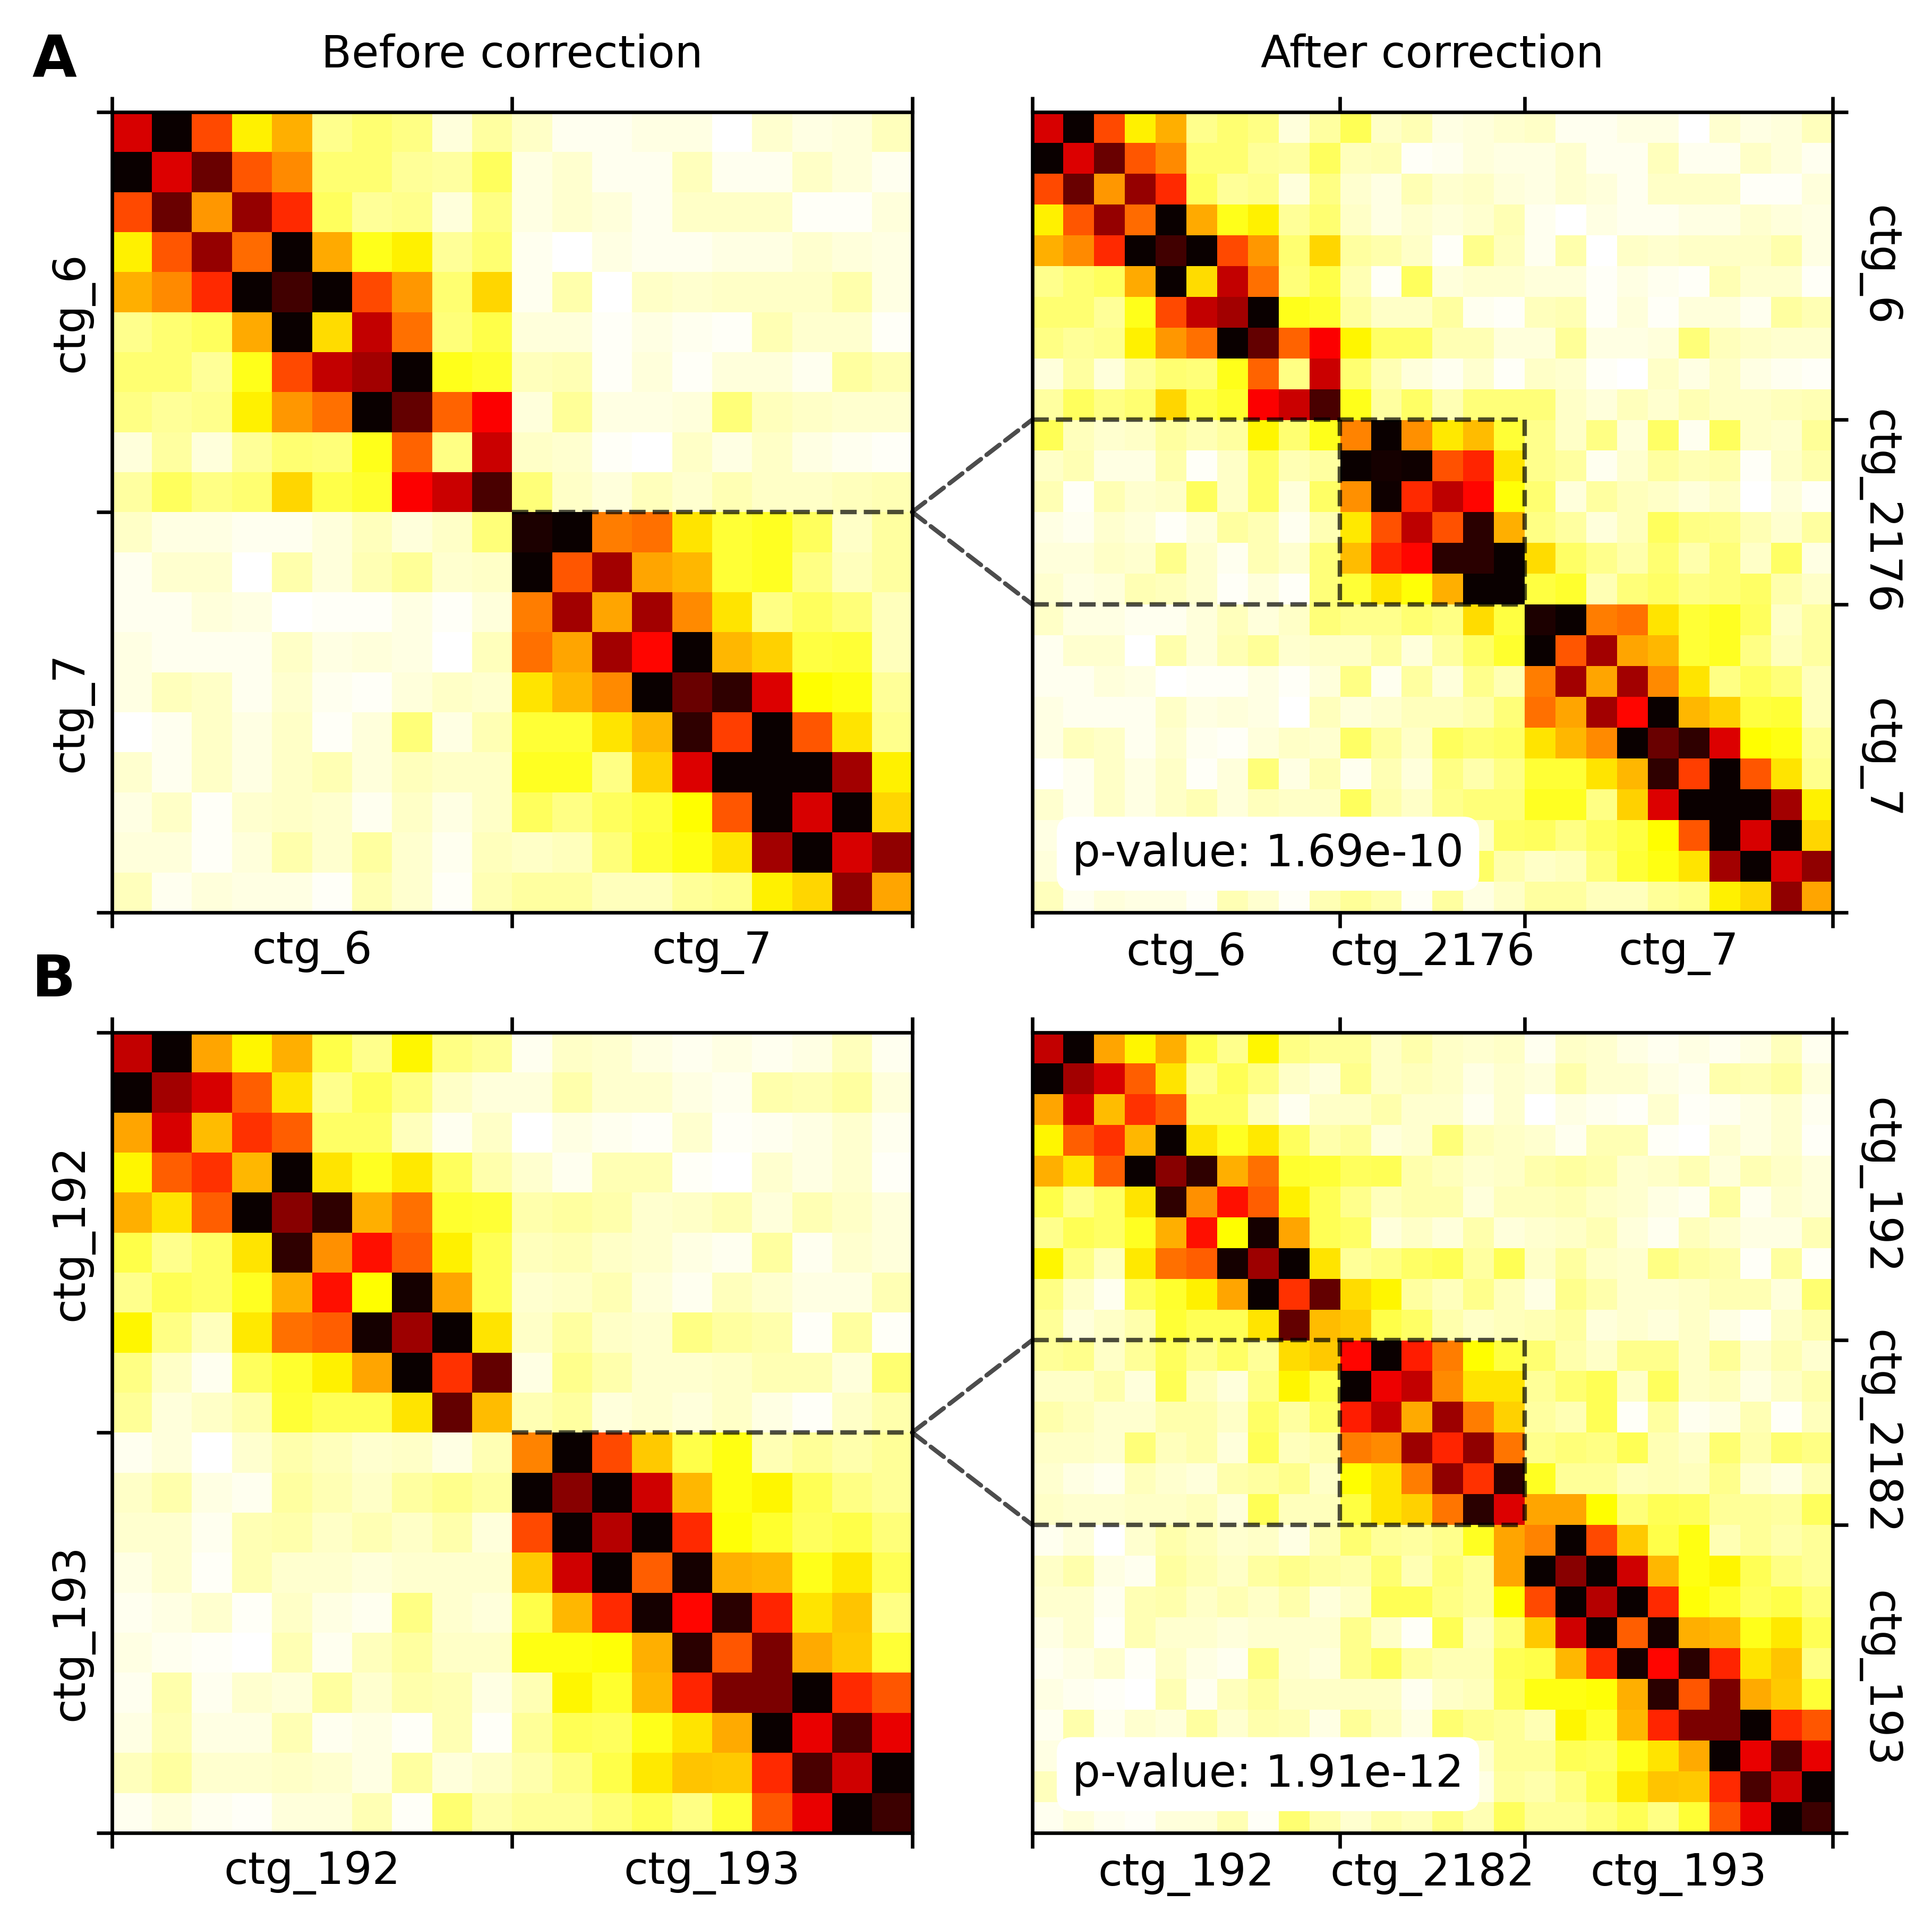

In [9]:
gen_improvfig(
    [[["contig_6:F", "contig_7:F"], ["contig_6:F", "contig_2176:F", "contig_7:F"]],[["contig_192:F", "contig_193:F"], ["contig_192:F", "contig_2182:F", "contig_193:F"]]], 
    cool, 
    savefig=f"PAPER.IMPRV.png",
    figsize=(6,6),
    fs=10
)

## SFigure

Contigs : contig_1066
CUM_SIZES : [0, 10, 20]
contig_1066:0, contig_1067:1
Contigs : contig_1066
Contigs : contig_2257
CUM_SIZES : [0, 10, 14, 24]
contig_1066:0, contig_2257:1
contig_1066:0, contig_1067:2
contig_2257:1, contig_1067:2
0.6
0.6
0.6
Contigs : contig_1039
CUM_SIZES : [0, 10, 20]
contig_1039:0, contig_1040:1
Contigs : contig_1039
Contigs : contig_2208
CUM_SIZES : [0, 10, 16, 26]
contig_1039:0, contig_2208:1
contig_1039:0, contig_1040:2
contig_2208:1, contig_1040:2
0.65
0.65
0.65
Contigs : contig_998
CUM_SIZES : [0, 10, 20]
contig_998:0, contig_999:1
Contigs : contig_998
Contigs : contig_2262
CUM_SIZES : [0, 10, 14, 24]
contig_998:0, contig_2262:1
contig_998:0, contig_999:2
contig_2262:1, contig_999:2
0.6
0.6
0.6


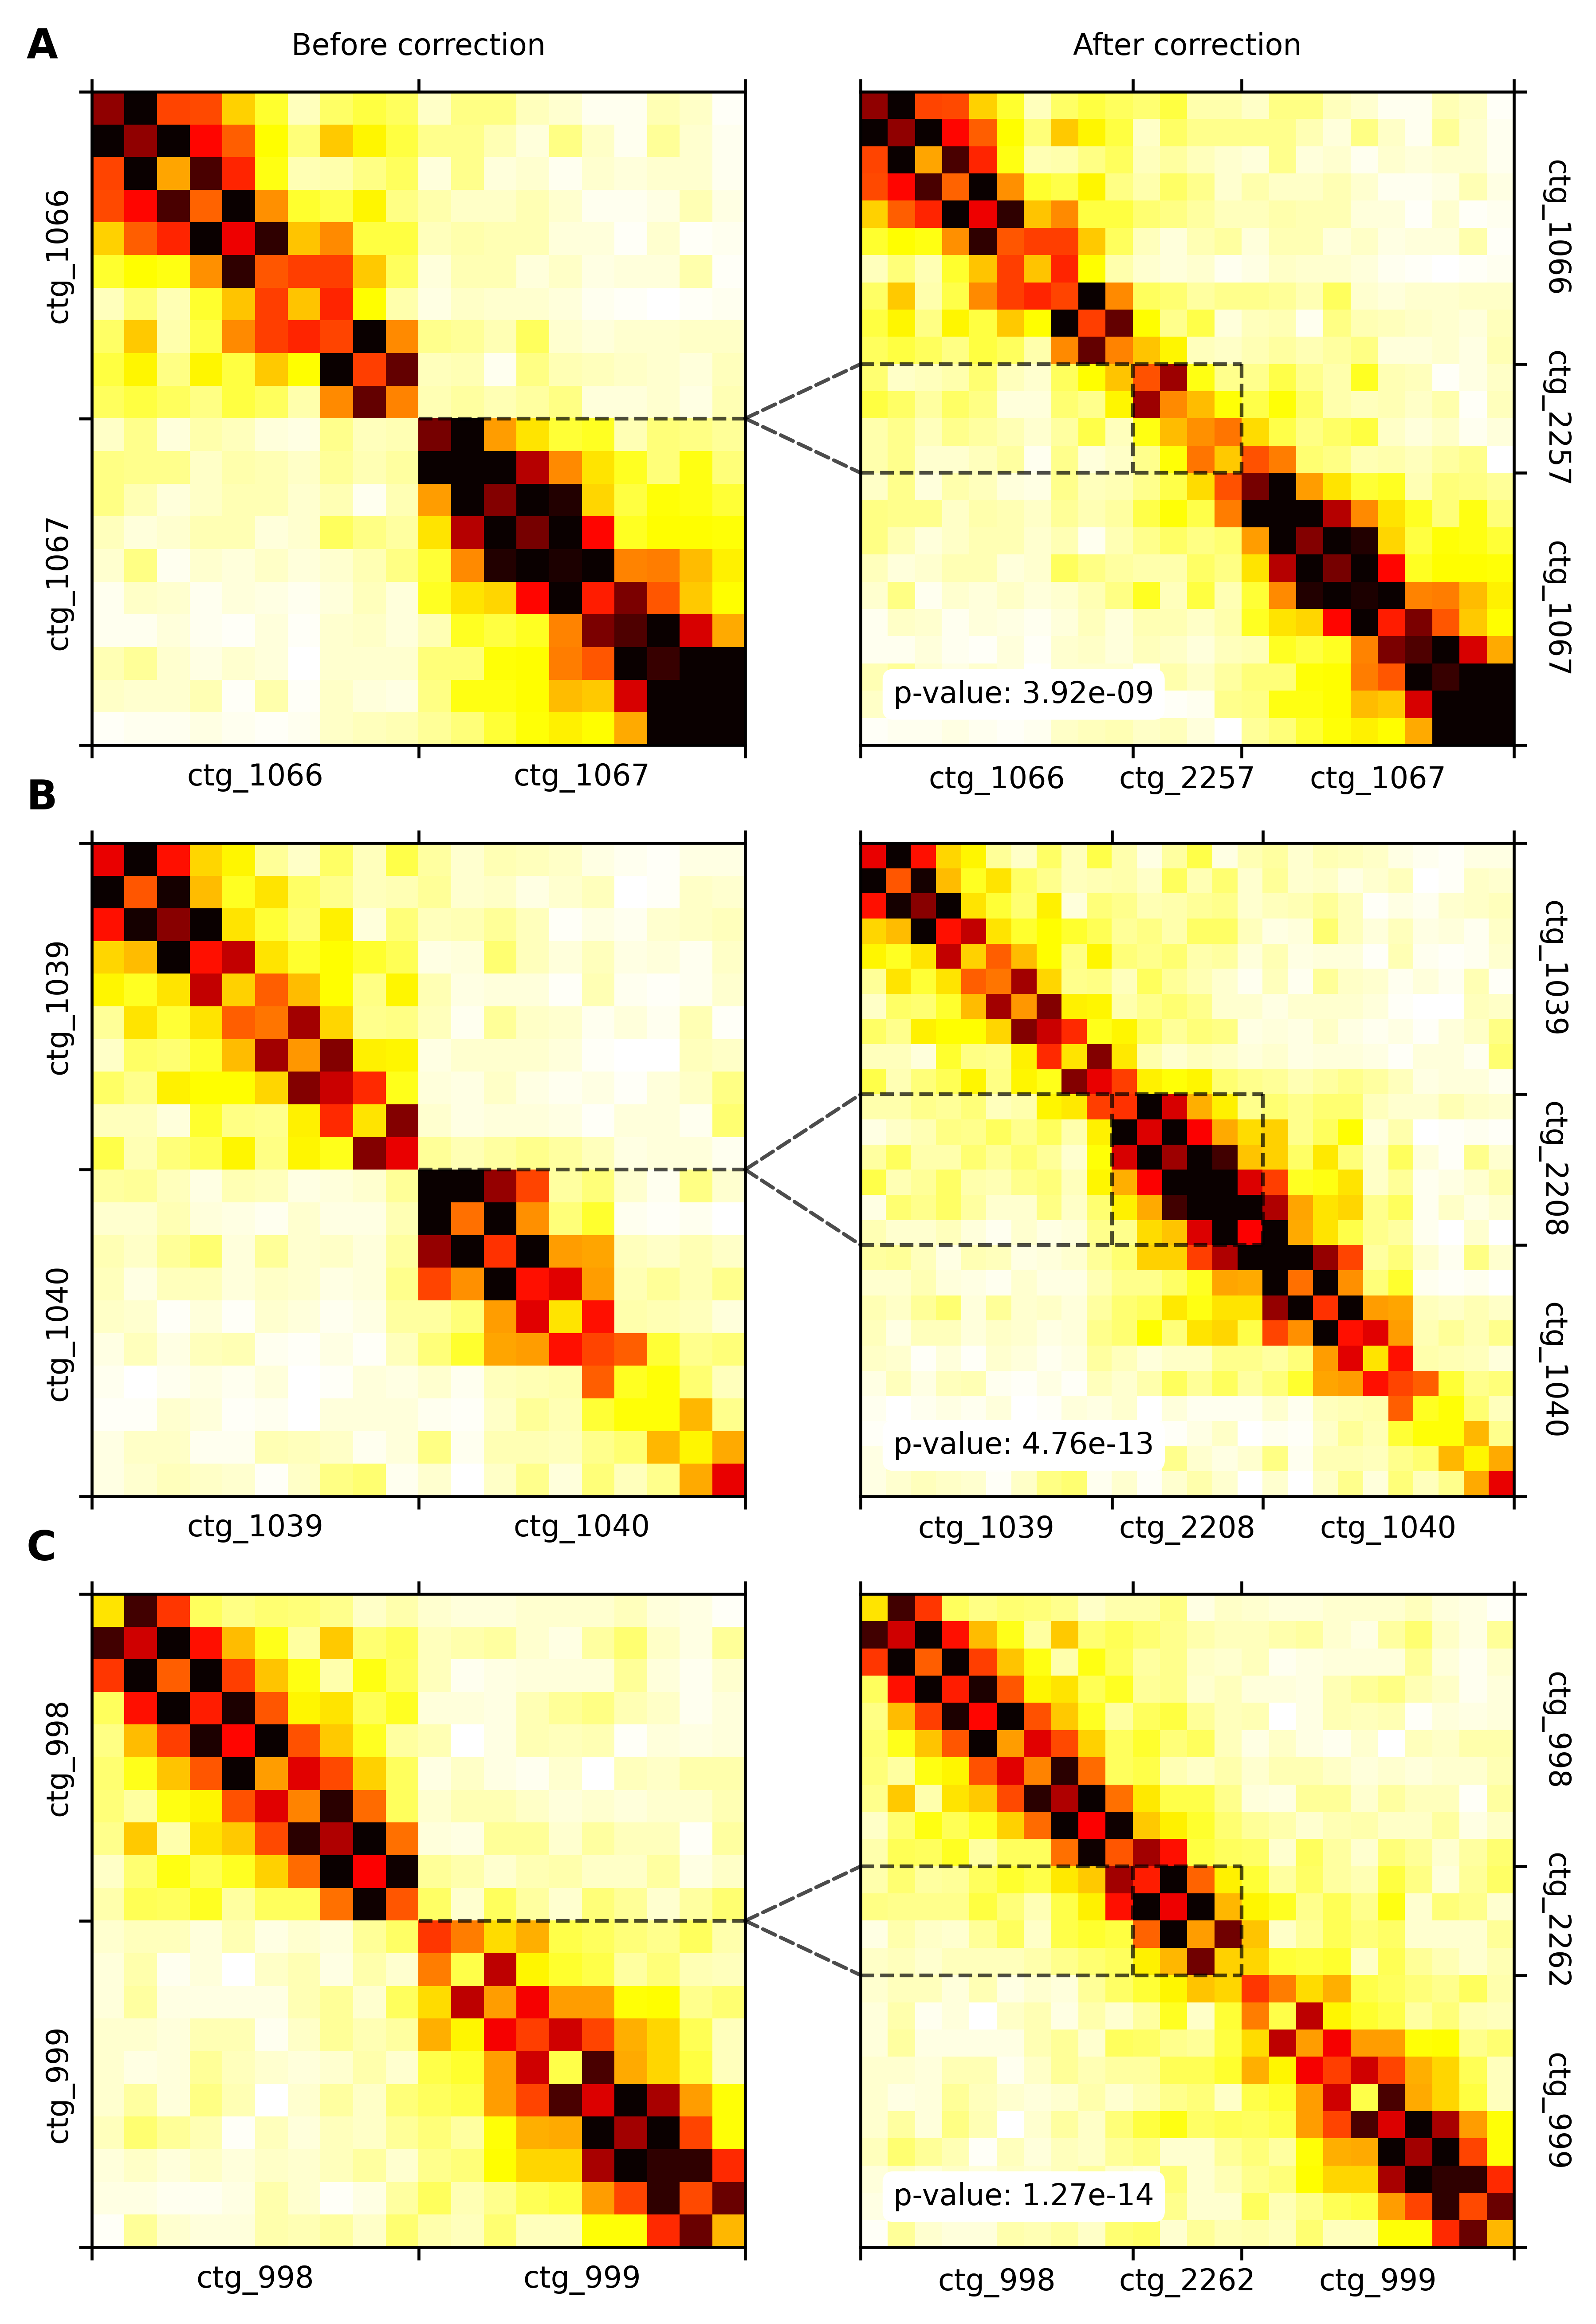

In [10]:
gen_improvfig(
    [[["contig_1066:F", "contig_1067:F"], ["contig_1066:F", "contig_2257:F", "contig_1067:F"]],
     [["contig_1039:F", "contig_1040:F"], ["contig_1039:F", "contig_2208:R", "contig_1040:F"]],
     [["contig_998:F", "contig_999:F"], ["contig_998:F", "contig_2262:R", "contig_999:F"]]],
    cool, 
    savefig=f"SUPP.PAPER.IMPRV.png",
    figsize=(6,9),
    fs=8
)